In [ ]:
import os
import numpy as np
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt

In [2]:
device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
print(f"Using {device} device")

Using cpu device


In [3]:
class NeuralNetwork(nn.Module):
    def __init__(self, n_in, n_hidden1, n_hidden2, n_out):
        super().__init__()

        self.layers = nn.Sequential(
            nn.Linear(n_in, n_hidden1),
            nn.ReLU(),
            nn.Linear(n_hidden1, n_hidden2),
            nn.ReLU(),
            nn.Linear(n_hidden2, n_out)
        )
        
    def forward(self, x):
        out = self.layers(x)
        return out

In [4]:
model = NeuralNetwork(6, 64, 64, 2).to(device)
print(model)

NeuralNetwork(
  (layers): Sequential(
    (0): Linear(in_features=6, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=2, bias=True)
  )
)


In [5]:
def load_features(feature_path):
    listing = os.listdir(feature_path)
    listing = [fname for fname in listing if fname.endswith('.npy')]

    dummy = np.load(f"{feature_path}/{listing[0]}")
    X = np.zeros( (len(listing),dummy.shape[0]) )
    Y = np.zeros( len(listing) )


    for i,file_name in enumerate(listing):
        y = int(file_name.split('_')[-2])
        assert(y == 0 or y == 1)
        x = np.load(f"{feature_path}/{file_name}")

        X[i,:] = x
        Y[i] = y
    
    return X,Y

# scaling between -1 and 1
def normalize_features(X):
    max_feat = np.max(X, axis=0)
    min_feat = np.min(X, axis=0)
    
    return (X - min_feat)/(max_feat - min_feat)*2 - 1


feature_path = f"files/extracted_features_mat/"
X,Y = load_features(feature_path)
#print(X)
#print(Y)

# splitting the dataset
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test= train_test_split(X, Y, test_size=0.3, random_state=42, stratify=Y)
print(f'Train size: {len(X_train)}, Test size: {len(X_test)}')

# show distribution of labels in train and test set
from collections import Counter
train_labels = y_train
test_labels = y_test
print(f'Train label distribution: {Counter(train_labels)}')
print(f'Test label distribution: {Counter(test_labels)}')

# from numpy to torch
X_train = torch.tensor(X_train, dtype=torch.float32)
X_test  = torch.tensor(X_test,  dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.long)
y_test  = torch.tensor(y_test,  dtype=torch.long)

# create Datasets
train_dataset = TensorDataset(X_train, y_train)
test_dataset  = TensorDataset(X_test, y_test)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
#test_loader  = DataLoader(test_dataset,  batch_size=32, shuffle=False)

from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler((-1,1))
X_train = torch.Tensor(scaler.fit_transform(X_train))
X_test = torch.Tensor(scaler.transform(X_test))

#print(X_test.min(dim=0))
#print(X_test.max(dim=0))


Train size: 130, Test size: 56
Train label distribution: Counter({np.float64(1.0): 130})
Test label distribution: Counter({np.float64(1.0): 56})


----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Linear-1                   [-1, 64]             384
              ReLU-2                   [-1, 64]               0
            Linear-3                   [-1, 64]           4,160
              ReLU-4                   [-1, 64]               0
            Linear-5                    [-1, 2]             130
Total params: 4,674
Trainable params: 4,674
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.02
Estimated Total Size (MB): 0.02
----------------------------------------------------------------
Epoch [1/20] - Loss: 0.6623
Epoch [2/20] - Loss: 0.3999
Epoch [3/20] - Loss: 0.2336
Epoch [4/20] - Loss: 0.1247
Epoch [5/20] - Loss: 0.0570
Epoch [6/20] - Loss: 0.0260
Epoch [7/20] - Loss: 0.0136
Epoch [8/20] - Loss: 0.0075
Epoch [9/20] -

Text(0.5, 1.0, 'Training Loss over Epochs')

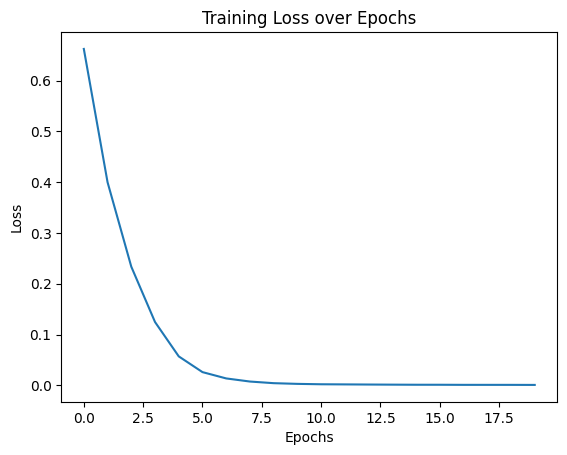

In [ ]:
from torchsummary import summary

input_size = X_train.shape[1]
model = NeuralNetwork(input_size, 64, 64, 2)


# show model summary
summary(model, input_size=(input_size,))

# loss Funktion festlegen
loss_fn = nn.CrossEntropyLoss() # weights !!!
# Optimieren definieren
optimizer = torch.optim.Adam(model.parameters(), lr=0.002)

epochs = 20
losses = []
for epoch in range(epochs):
    model.train()
    epoch_loss = 0.0

    for batch_X, batch_Y in train_loader:
        # Forward
        outputs = model(batch_X)
        loss = loss_fn(outputs, batch_Y)

        # Backward
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    print(f"Epoch [{epoch+1}/{epochs}] - Loss: {epoch_loss / len(train_loader):.4f}")
    losses.append(epoch_loss / len(train_loader))


plt.plot(range(epochs), losses)
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training Loss over Epochs')

c:\Users\gross\Desktop\IAML\Labor\.venv\lib\site-packages\sklearn\metrics\_classification.py:534: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


Accuracy on train set: 100.00%


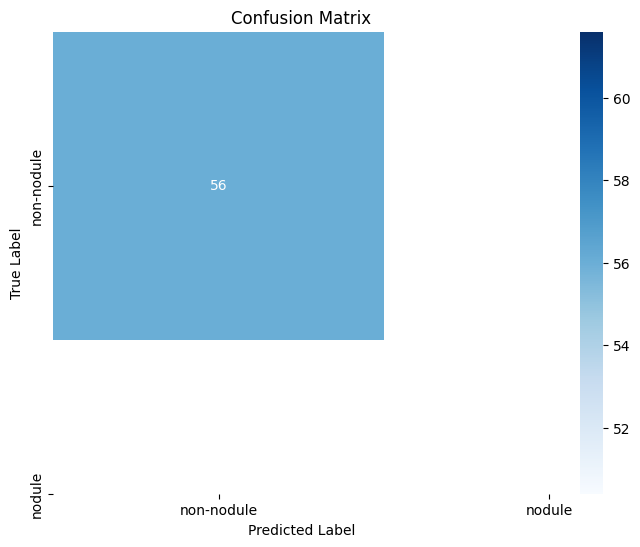

In [7]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

model.eval()

classes = ['non-nodule', 'nodule']

with torch.no_grad():
    test_outputs = model(X_test)
    _, predicted = torch.max(test_outputs.data, dim=1)
    confmat = confusion_matrix(y_test.numpy(), predicted.numpy())
    
# show confusion matrix
import seaborn as sns
plt.figure(figsize=(8,6))
sns.heatmap(confmat, annot=True, fmt='g', cmap='Blues', xticklabels=classes, yticklabels=classes)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')

# calculate accuracy from confusion matrix

accuracy = np.diag(confmat).sum() / confmat.sum()
print(f'Accuracy on train set: {accuracy.item()*100:.2f}%')